# **EDA**

`reddit_clean` and `rappler_clean` will be used.

In [6]:
!pip install matplotlib seaborn wordcloud nltk pandas

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached wordcloud-1.9.4-cp313-cp313-macosx_10_13_x86_64.whl.metadata (3.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 1.5 MB/s  0:00:05m0:00:0100:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached wordcloud-1.9.4-cp313-cp313-macosx_10_13_x86_64.whl (172 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 656.3 kB/s  0:00:02 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 587.2 kB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 509.5 kB/s  0:00:10 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [seaborn]0/11 [seaborn]d]]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from wordcloud import WordCloud
from wordcloud import STOPWORDS

reddit_clean = pd.read_csv(r"../data/Reddit/reddit_clean.csv")
rappler_clean = pd.read_csv(r"../data/News/rappler_clean.csv")

reddit_clean.info()
rappler_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12730 entries, 0 to 12729
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   post_title   12730 non-null  object
 1   post_url     12730 non-null  object
 2   comment      12503 non-null  object
 3   post_body    227 non-null    object
 4   created_utc  12730 non-null  object
 5   post_full    12730 non-null  object
dtypes: object(6)
memory usage: 596.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           121 non-null    object
 1   link            121 non-null    object
 2   date_published  121 non-null    object
 3   text            121 non-null    object
 4   cleaned_text    121 non-null    object
dtypes: object(5)
memory usage: 4.9+ KB


In [8]:
def generate_wordcloud(text_series, title, extra_stopwords=None):
    all_text = ' '.join(text_series)
    
    stopwords = set(STOPWORDS)
    if extra_stopwords:
        stopwords.update(extra_stopwords)
    
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(all_text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# --- Function to compute text stats ---
def add_text_stats(df, column):
    df['text_length'] = df[column].apply(len)
    df['word_count'] = df[column].apply(lambda x: len(x.split()))
    return df

# --- Function to plot Seaborn visualizations ---
def plot_text_stats(df, dataset_name):
    plt.figure(figsize=(12,5))
    
    # Text length histogram
    plt.subplot(1,2,1)
    sns.histplot(df['text_length'], bins=30, kde=True, color='skyblue')
    plt.title(f'{dataset_name} Text Length Distribution')
    plt.xlabel('Characters')
    
    # Word count histogram
    plt.subplot(1,2,2)
    sns.histplot(df['word_count'], bins=30, kde=True, color='salmon')
    plt.title(f'{dataset_name} Word Count Distribution')
    plt.xlabel('Words')
    
    plt.tight_layout()
    plt.show()
    

Reddit Text Stats Summary:
        text_length   word_count
count  12730.000000  12730.00000
mean      99.799921     15.90055
std      126.707288     20.28687
min        4.000000      1.00000
25%       55.000000      9.00000
50%       72.000000     12.00000
75%      114.000000     20.00000
max     6082.000000   1006.00000


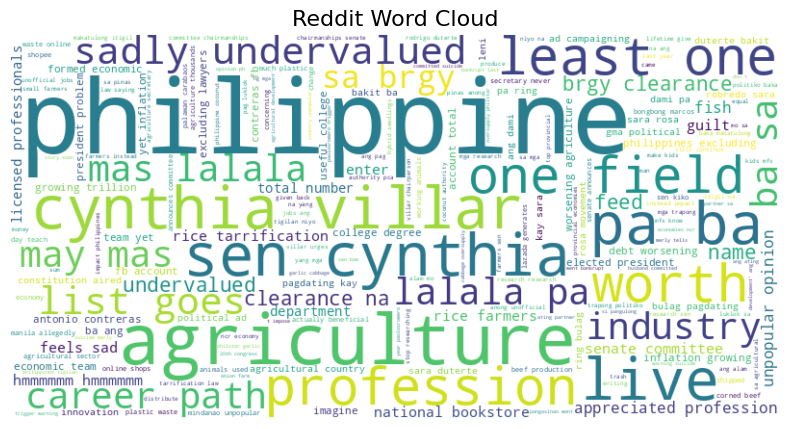

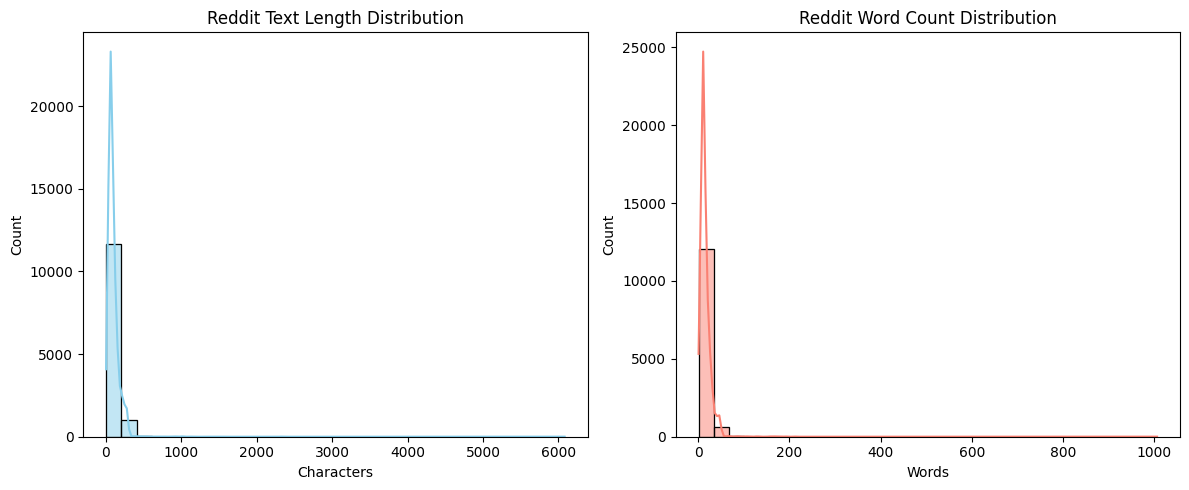

In [21]:
reddit_stopwords = {'reddit', 'like', 'just', 'people', 'know', 'get', 'think', 'time', 'make', 'good','hmmmmm','pa ba','list goes'}

reddit_clean = add_text_stats(reddit_clean, "post_full")
print("Reddit Text Stats Summary:")
print(reddit_clean[['text_length', 'word_count']].describe())
generate_wordcloud(reddit_clean['post_full'], "Reddit Word Cloud")
plot_text_stats(reddit_clean, "Reddit")

Rappler Text Stats Summary:
        text_length   word_count
count    121.000000   121.000000
mean    3791.082645   595.752066
std     2110.447329   334.902630
min      437.000000    67.000000
25%     2191.000000   341.000000
50%     3295.000000   509.000000
75%     4873.000000   738.000000
max    10015.000000  1647.000000


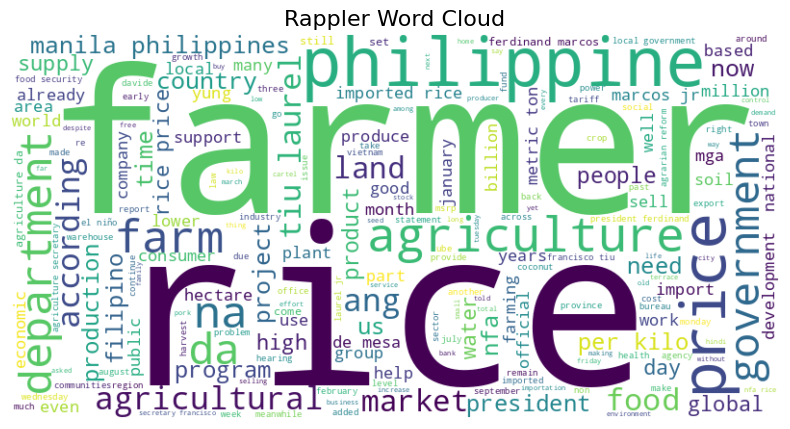

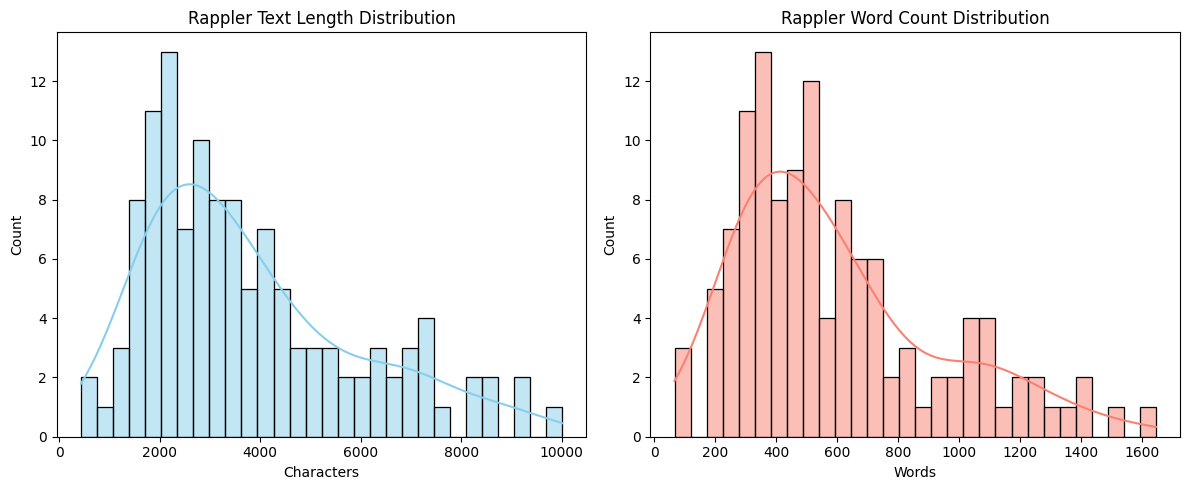

In [17]:
rappler_stopwords = {'said', 'will', 'also', 'one', 'new', 'may', 'two', 'first', 'last', 'year', 's','rappler','ay','ng','sa','po','de mesa'}

rappler_clean = add_text_stats(rappler_clean, "cleaned_text")
print("Rappler Text Stats Summary:")
print(rappler_clean[['text_length', 'word_count']].describe())
generate_wordcloud(rappler_clean['cleaned_text'], "Rappler Word Cloud", extra_stopwords=rappler_stopwords)
plot_text_stats(rappler_clean, "Rappler")


---
Getting top words

In [11]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

def get_top_words(text_series, n=20, extra_stopwords=None):
    """
    Returns top n frequent words (excluding stopwords)
    """
    all_text = ' '.join(text_series).lower().split()
    stop_words_set = set(stopwords.words('english'))
    if extra_stopwords:
        stop_words_set.update(extra_stopwords)
    
    filtered_words = [w for w in all_text if w.isalpha() and w not in stop_words_set]
    word_freq = Counter(filtered_words)
    return word_freq.most_common(n)


[nltk_data] Downloading package stopwords to /Users/uwie/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
reddit_top_words = get_top_words(reddit_clean['post_full'], n=20)
print("Reddit Top 20 Words:")
print(reddit_top_words)

rappler_top_words = get_top_words(rappler_clean['cleaned_text'], n=20)
print("Rappler Top 20 Words:")
print(rappler_top_words)


Reddit Top 20 Words:
[('agriculture', 2568), ('sa', 2002), ('na', 1554), ('ang', 1302), ('ng', 1264), ('rice', 1118), ('agricultural', 1112), ('philippines', 1005), ('profession', 918), ('pa', 829), ('ba', 782), ('department', 636), ('may', 634), ('cynthia', 632), ('committee', 601), ('senate', 597), ('mga', 593), ('one', 591), ('marcos', 581), ('farmers', 565)]
Rappler Top 20 Words:
[('rice', 478), ('said', 405), ('ng', 223), ('agriculture', 215), ('food', 205), ('farmers', 186), ('philippines', 183), ('sa', 182), ('also', 181), ('na', 163), ('prices', 142), ('government', 138), ('agricultural', 138), ('price', 138), ('department', 132), ('ang', 129), ('would', 123), ('da', 120), ('marcos', 117), ('per', 117)]


In [22]:
# Define Filipino stopwords
filipino_stopwords = {'na', 'sa', 'ang', 'mga', 'pa', 'ba', 'ng', 'ay', 'si', 'ni', 'kay', 'may', 'also', 'mas'}

# Get top words excluding English + Filipino stopwords
reddit_top_words = get_top_words(
    reddit_clean['post_full'], 
    n=20, 
    extra_stopwords=filipino_stopwords.union(reddit_stopwords)
)
print("Reddit Top 20 Words (Filipino Stopwords Removed):")
print(reddit_top_words)

rappler_top_words = get_top_words(
    rappler_clean['cleaned_text'], 
    n=20, 
    extra_stopwords=filipino_stopwords.union(rappler_stopwords)
)
print("Rappler Top 20 Words (Filipino Stopwords Removed):")
print(rappler_top_words)



Reddit Top 20 Words (Filipino Stopwords Removed):
[('agriculture', 2568), ('rice', 1118), ('agricultural', 1112), ('philippines', 1005), ('profession', 918), ('department', 636), ('cynthia', 632), ('committee', 601), ('senate', 597), ('one', 591), ('marcos', 581), ('farmers', 565), ('goes', 563), ('clearance', 560), ('fish', 505), ('least', 496), ('bakit', 495), ('live', 480), ('list', 479), ('field', 479)]
Rappler Top 20 Words (Filipino Stopwords Removed):
[('rice', 478), ('agriculture', 215), ('food', 205), ('farmers', 186), ('philippines', 183), ('prices', 142), ('government', 138), ('agricultural', 138), ('price', 138), ('department', 132), ('would', 123), ('da', 120), ('marcos', 117), ('per', 117), ('laurel', 116), ('local', 108), ('according', 100), ('president', 100), ('national', 98), ('nfa', 88)]


---
Post frequency over time

In [14]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def plot_posts_over_time(df, date_column, dataset_name):
    """
    Plots number of posts/articles per day using Seaborn
    """
    # Ensure datetime
    df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
    
    # Count posts per day
    ts = df.groupby(df[date_column].dt.date).size().reset_index(name='count')
    ts.rename(columns={date_column: 'date'}, inplace=True)
    
    # Plot with Seaborn
    plt.figure(figsize=(14,5))
    sns.lineplot(data=ts, x='date', y='count', marker='o')
    plt.title(f'{dataset_name} Posts Over Time', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Posts', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


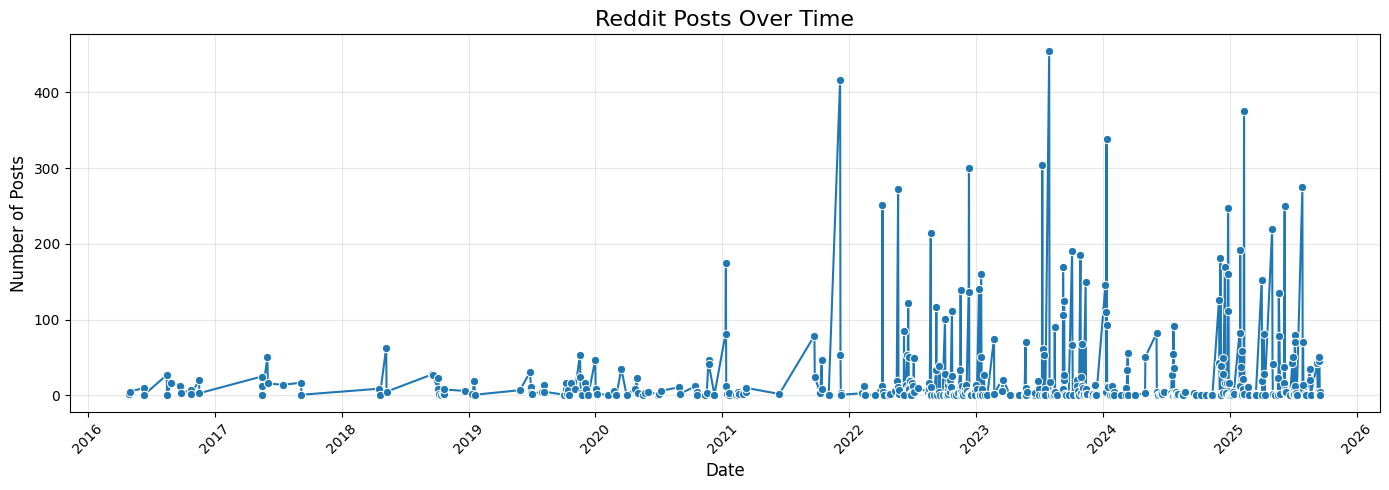

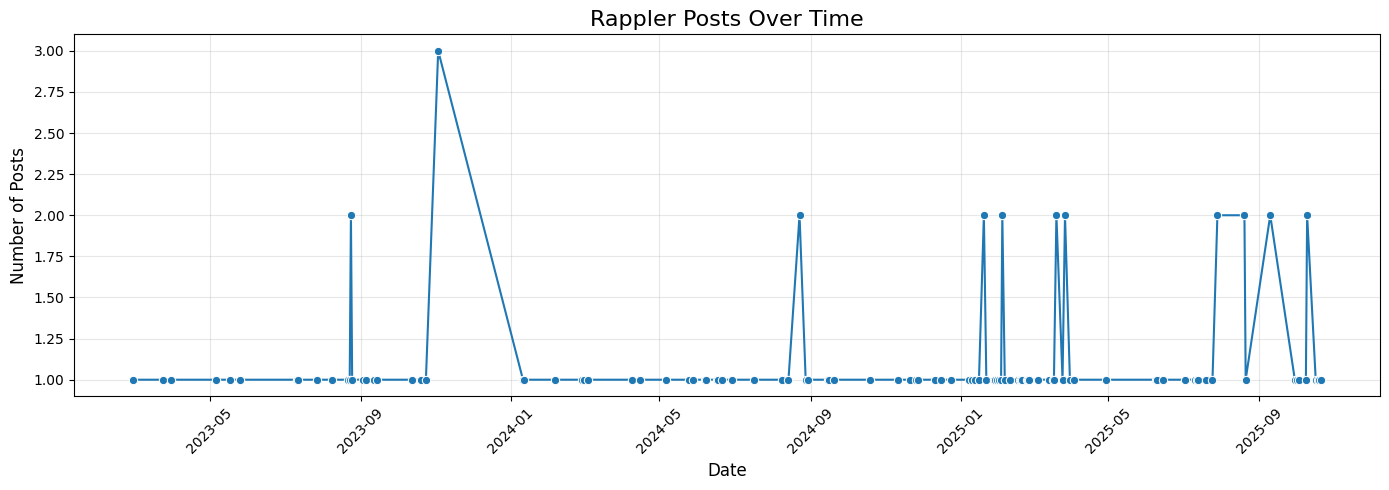

In [15]:
plot_posts_over_time(reddit_clean, 'created_utc', 'Reddit')
plot_posts_over_time(rappler_clean, 'date_published', 'Rappler')


---
**Topic Modelling**

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.corpus import stopwords
import re

pd.set_option('display.max_rows', None)

nltk.download('stopwords')
stop_words = stopwords.words('english')

reddit_clean = pd.read_csv("../data/Reddit/reddit_clean.csv")

reddit_clean['text'] = reddit_clean['post_full'].fillna('') + " " + reddit_clean['comment'].fillna('')

print(reddit_clean.loc[0, 'text'])



[nltk_data] Downloading package stopwords to /Users/uwie/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


sen. marcoleta to hold blue ribbon committee, sen. bam on education and sen. kiko on agriculture oh god, marcos camp is in danger of opening a can of worms from sen. marcoleta. lahat ng corruption from the marcos admin ibunyag and protect vp sara from anything under the sun. no one can stop marcoleta. no one. 
